In [34]:
from __future__ import annotations

from dataclasses import dataclass, field
from pathlib import Path
from typing import Iterable, Sequence, Mapping
from collections.abc import Sequence

import os 
import glob 
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.colors import Normalize
from matplotlib.colors import BoundaryNorm, ListedColormap, LinearSegmentedColormap
from matplotlib.colors import TwoSlopeNorm


In [65]:
@dataclass(frozen=True)
class S2SSkillPlotConfig:
    """
    Plot config for BOTH:
      (A) skill files: s2s_skill_<GROUP>_<FREQ>_<RUN>_<OBS>_<REGION>_<VAR>.nc
      (B) diagnostic regional files: s2s_regional_tcc_rmse_<GROUP>_<OBS>_<PERIOD>_<EXP>_<VAR>.nc
    """
    skill_dir: Path
    file_glob: str = "s2s_skill_*_*.nc"

    # Mode switch
    diag_mode: bool = False  # False -> s2s_skill_*, True -> s2s_regional_tcc_rmse_*

    # Optional filters (diag mode)
    groups_include: tuple[str, ...] = ()      # e.g. ("Jan2012","Jun2012")
    periods_include: tuple[str, ...] = ()     # e.g. ("201201-201203",)
    obs_include: tuple[str, ...] = ()         # e.g. ("ERA5","GPM","NOAA-OLR")

    # Obs selection
    default_obs: str = "ERA5"
    obs_by_var: dict[str, str] = field(default_factory=dict)

    # What to plot
    vars_include: tuple[str, ...] = ()
    exp_include: tuple[str, ...] = ()
    exp_order: tuple[str, ...] = ()

    # Regions
    regions_include: tuple[str, ...] = ()
    region_order: tuple[str, ...] = ()

    # Lead bins (skill-mode)
    lead_bins: tuple[tuple[int, int], ...] = ((1, 14), (15, 28), (29, 42), (43, 56))
    lead_bin_labels: tuple[str, ...] = ("Wk1–2", "Wk3–4", "Wk5–6", "Wk7–8")

    # Output
    out_dir: Path | None = None
    dpi: int = 300
    tag: str = ""

    # Optional: RMSE normalization
    rmse_norm_mode: str | None = "baseline"  # None | "baseline"
    rmse_norm_ctrl_by_group: dict[str, str] = field(default_factory=lambda: {
        "Jan2012": "CTRL10-S0",
        "Jun2012": "CTRL10-S1",
    })
    rmse_eps: float = 1e-12

    # Difference mode (optional)
    baseline_exp: str | None = None
    plot_difference: bool = False

    # xarray join control
    concat_join: str = "outer"

    # Debug
    debug: bool = False


# ----------------------------
# Plotter
# ----------------------------
class S2SSkillPlotter:
    def __init__(self, cfg: S2SSkillPlotConfig):
        self.cfg = cfg
        if self.cfg.out_dir:
            self.cfg.out_dir.mkdir(parents=True, exist_ok=True)
        self._files_cache: list[Path] | None = None

    # ---------- file discovery ----------
    def _discover_files(self) -> list[Path]:
        if self._files_cache is None:
            files = sorted(self.cfg.skill_dir.glob(self.cfg.file_glob))
            if not files:
                raise FileNotFoundError(f"No files matched {self.cfg.skill_dir}/{self.cfg.file_glob}")
            self._files_cache = files
        return self._files_cache

    @staticmethod
    def _parse_tokens(p: Path) -> list[str]:
        return p.stem.split("_")

    def _obs_for_var(self, var_name: str) -> str:
        return self.cfg.obs_by_var.get(var_name, self.cfg.default_obs)
        
    @staticmethod
    def _make_discrete_cmap_norm(
        cmap: str,
        vmin: float,
        vmax: float,
        nlev: int,
    ) -> tuple[ListedColormap, BoundaryNorm, np.ndarray]:
        """
        Discrete colormap for bounded metrics (e.g. TCC in [0,1]).
        Uses end colors of the colormap for extensions to avoid artifacts.
        """
        if nlev < 2:
            raise ValueError(f"nlev must be >= 2 (got {nlev})")
        if vmax <= vmin:
            raise ValueError(f"vmax must be > vmin")

        n_color_bins = nlev - 1
        
        # Discrete bin edges
        levels = np.linspace(vmin, vmax, nlev)
        
        # Sample base colormap INCLUDING two extra colors for under/over
        base = plt.get_cmap(cmap, n_color_bins + 2)
        colors = base(np.linspace(0, 1, n_color_bins + 2))
        
        # Drop the first color (reserved for "under")
        # Keep the last color (reserved for "over")
        cmap_discrete = ListedColormap(colors[1:-1])
        
        # Set extend colors explicitly
        cmap_discrete.set_under(colors[0])
        cmap_discrete.set_over(colors[-1])
        
        # Norm for discrete bins
        norm = BoundaryNorm(levels, cmap_discrete.N, clip=False)

        return cmap_discrete, norm, levels

    def _make_diverging_discrete_cmap_norm(
        self,
        *,
        bounds: list[float],
        cmap_neg: str = "Blues_r",
        cmap_pos: str = "Reds",
        zero_color=(1, 1, 1, 1),
    ):
        """
        Build a discrete diverging colormap with:
          - cool colors for < 0
          - warm colors for > 0
          - explicit zero boundary
    
        bounds: list of bin edges (must include 0)
        """
        bounds = np.asarray(bounds, dtype=float)
        if 0.0 not in bounds:
            raise ValueError("bounds must include 0 for diverging colormap")
    
        # split bounds
        neg_bounds = bounds[bounds < 0]
        pos_bounds = bounds[bounds > 0]
    
        nneg = len(neg_bounds)
        npos = len(pos_bounds)
    
        # sample colormaps
        neg_cmap = plt.get_cmap(cmap_neg, nneg)
        pos_cmap = plt.get_cmap(cmap_pos, npos)
    
        colors = []
    
        # negative side
        for i in range(nneg):
            colors.append(neg_cmap(i))
    
        # optional neutral zero bin
        colors.append(zero_color)
    
        # positive side
        for i in range(npos):
            colors.append(pos_cmap(i))
    
        cmap = ListedColormap(colors)
    
        # under / over colors
        cmap.set_under(neg_cmap(0))
        cmap.set_over(pos_cmap(npos - 1))
    
        norm = BoundaryNorm(bounds, cmap.N, clip=False)
    
        return cmap, norm, bounds.tolist()
        
    # ---------- diag filename parsing ----------
    def _parse_diag_filename(self, p: Path) -> dict[str, str]:
        """
        s2s_regional_tcc_rmse_<GROUP>_<OBS>_<PERIOD>_<EXP>_<VAR>.nc
        """
        parts = p.stem.split("_")
        if len(parts) < 9:
            raise ValueError(f"Unexpected diag filename format: {p.name} (tokens={len(parts)})")
        # parts[0]=s2s, 1=regional, 2=tcc, 3=rmse
        group = parts[4]
        obs = parts[5]
        period = parts[6]
        exp = parts[7]
        var = parts[8]  # if vars can include "_" use "_".join(parts[8:])
        return dict(group=group, obs=obs, period=period, exp=exp, var=var)

    def _diag_matches_filters(self, meta: dict[str, str]) -> bool:
        if self.cfg.groups_include and meta["group"] not in set(self.cfg.groups_include):
            return False
        if self.cfg.periods_include and meta["period"] not in set(self.cfg.periods_include):
            return False
        if self.cfg.obs_include and meta["obs"] not in set(self.cfg.obs_include):
            return False
        return True

    # ---------- list vars ----------
    def list_vars(self) -> list[str]:
        files = self._discover_files()
        if self.cfg.diag_mode:
            vars_ = []
            for p in files:
                if "s2s_regional_tcc_rmse_" not in p.name:
                    continue
                meta = self._parse_diag_filename(p)
                if not self._diag_matches_filters(meta):
                    continue
                vars_.append(meta["var"])
        else:
            vars_ = [p.stem.split("_")[-1] for p in files if p.name.startswith("s2s_skill_")]

        if self.cfg.vars_include:
            vars_ = [v for v in vars_ if v in set(self.cfg.vars_include)]
        return sorted(dict.fromkeys(vars_))

    # ---------- list regions ----------
    def list_regions(self, var_name: str | None = None) -> list[str]:
        vars_ = self.list_vars()
        if not vars_:
            raise ValueError("No variables found to infer regions.")
        v0 = var_name or vars_[0]
        ds0 = self.open_var(v0, region=None, debug=self.cfg.debug)

        if "region" not in ds0.dims and "region" not in ds0.coords:
            raise KeyError(f"No 'region' dim/coord found. dims={dict(ds0.dims)} coords={list(ds0.coords)}")

        regs = [str(r) for r in ds0["region"].values.tolist()]

        if self.cfg.regions_include:
            regs = [r for r in regs if r in set(self.cfg.regions_include)]

        if self.cfg.region_order:
            regs = [r for r in self.cfg.region_order if r in set(regs)]
        else:
            regs = sorted(dict.fromkeys(regs))
        return regs

    # ---------- experiment selection ----------
    def _select_exps(self, ds: xr.Dataset) -> xr.Dataset:
        if "exp" not in ds.coords and "exp" not in ds.dims:
            return ds
        exps = [str(e) for e in ds["exp"].values.tolist()]
        if self.cfg.exp_include:
            keep = [e for e in exps if e in set(self.cfg.exp_include)]
        else:
            keep = exps
        if self.cfg.exp_order:
            keep = [e for e in self.cfg.exp_order if e in set(keep)]
        if not keep:
            raise ValueError(f"No experiments selected. Available={exps}, requested exp_order={self.cfg.exp_order}")
        return ds.sel(exp=keep)

    # ---------- lead/window helpers ----------
    @staticmethod
    def _get_lead_days(ds: xr.Dataset) -> xr.DataArray:
        if "lead" in ds.coords:
            return ds["lead"].astype(float)
        if "lead_days" in ds:
            return ds["lead_days"].astype(float)
        if "time" in ds.dims:
            return xr.DataArray(np.arange(ds.sizes["time"], dtype=float), dims=("time",), name="lead_days")
        raise KeyError("No lead-like coordinate found.")

    @staticmethod
    def _bin_mask(lead: xr.DataArray, a: int, b: int) -> xr.DataArray:
        return (lead >= float(a)) & (lead <= float(b))

    def _bin_mean(self, da: xr.DataArray, lead: xr.DataArray, a: int, b: int) -> xr.DataArray:
        m = self._bin_mask(lead, a, b)
        dim = lead.dims[0]
        return da.where(m).mean(dim, skipna=True)

    # ---------- metric getter ----------
    def _get_metric_da(self, ds: xr.Dataset, metric: str) -> xr.DataArray:
        if metric not in ds:
            raise KeyError(f"Metric '{metric}' not found. Available: {list(ds.data_vars)}")
        return ds[metric]

    # ---------- open var ----------
    def open_var(self, var_name: str, region: str | None = None, debug: bool = False) -> xr.Dataset:
        """
        Unified loader:
          - diag_mode: concat across files into ds(exp, region, window, ...)
          - skill_mode: open single file per var (obs chosen by obs_by_var/default_obs)
        """
        files = self._discover_files()

        if self.cfg.diag_mode:
            want_obs = self._obs_for_var(var_name)

            ds_list: list[xr.Dataset] = []
            for p in files:
                if "s2s_regional_tcc_rmse_" not in p.name:
                    continue
                meta = self._parse_diag_filename(p)
                if meta["var"] != var_name:
                    continue
                if not self._diag_matches_filters(meta):
                    continue
                if meta["obs"] != want_obs:
                    continue

                if debug:
                    print(f"[open_var diag] {p.name}")

                ds0 = xr.open_dataset(p)

                # Always add exp dim with label (robust; avoids da missing exp coord)
                exp_label = f"{meta['group']}:{meta['exp']}"
                if "exp" not in ds0.dims:
                    ds0 = ds0.expand_dims(exp=[exp_label])

                ds_list.append(ds0)

            if not ds_list:
                raise FileNotFoundError(
                    f"No diag file found for var={var_name}, obs={want_obs} in {self.cfg.skill_dir}"
                )

            ds_cat = xr.concat(
                ds_list,
                dim="exp",
                data_vars="minimal",
                coords="minimal",
                compat="override",
                join=self.cfg.concat_join,
            )

            if region is not None:
                if "region" in ds_cat.dims or "region" in ds_cat.coords:
                    ds_cat = ds_cat.sel(region=region)

            ds_cat = self._select_exps(ds_cat).load()
            return ds_cat

        # ---------------- skill-mode ----------------
        want_obs = self._obs_for_var(var_name)
        cand = []
        for p in files:
            if not p.name.startswith("s2s_skill_"):
                continue
            parts = p.stem.split("_")
            if len(parts) < 7:
                continue
            fobs = parts[-2]
            fvar = parts[-1]
            if fvar == var_name and fobs == want_obs:
                cand.append(p)

        if not cand:
            raise FileNotFoundError(f"No skill file found for var={var_name}, obs={want_obs}")

        f0 = sorted(cand)[0]
        if debug:
            print(f"[open_var skill] {f0.name}")

        with xr.open_dataset(f0) as ds0:
            ds = ds0.copy(deep=False)

        if region is not None:
            if "region" in ds.dims or "region" in ds.coords:
                ds = ds.sel(region=region)

        ds = self._select_exps(ds)

        keep = [v for v in ds.data_vars if v.startswith(("ACC", "RMSE"))] + [v for v in ("lead_days",) if v in ds]
        ds = ds[keep].load()

        if "var" in ds.dims and ds.sizes.get("var", 0) == 1:
            ds = ds.isel(var=0, drop=True)
        return ds

    # ---------- exp helpers ----------
    @staticmethod
    def _strip_group(exp: str) -> str:
        return exp.split(":", 1)[-1]

    def _exps_for_group(self, exps_all: list[str], group: str) -> list[str]:
        out = []
        for e in exps_all:
            if ":" in e:
                if e.split(":", 1)[0] == group:
                    out.append(e)
            else:
                out.append(e)
        if self.cfg.exp_order:
            out = [e for e in self.cfg.exp_order if e in set(out)]
        return out

    # ---------- guide axes placement ----------
    def _guide_axes_rect(self, ax: plt.Axes, guide_loc: str, guide_size: float, pad: float = 0.01):
        bbox = ax.get_position()
        s = float(guide_size)

        loc = guide_loc.lower().replace("-", " ").strip()
        if loc == "right":
            loc = "upper right"
        if loc == "left":
            loc = "upper left"
        if loc == "top right":
            loc = "upper right"
        if loc == "top left":
            loc = "upper left"
        if loc == "bottom right":
            loc = "lower right"
        if loc == "bottom left":
            loc = "lower left"

        if "right" in loc:
            x0 = min(bbox.x1 + pad, 1.0 - s)
        else:
            x0 = max(bbox.x0 - pad - s, 0.0)

        if "upper" in loc:
            y0 = min(max(bbox.y1 - s, 0.0), 1.0 - s)
        else:
            y0 = max(bbox.y0, 0.0)

        return (x0, y0, s, s)

    # ----------------------------
    # PLOT: one region + one group + all vars
    # ----------------------------    
    def plot_quadrant_heatmap_one_region(
        self,
        group: str | Sequence[str],  # <<< CHANGED: allow 1 or 2 groups
        region: str,
        metric: str = "TCC_regional_ensmean",
        out_png: Path | None = None,
        show: bool = True,
        vmin: float | None = None,
        vmax: float | None = None,
        cmap: str = "RdBu_r",
        nlev: int = 11,
        edgecolor: str = "white",
        linewidth: float = 0.6,
        guide: bool = True,
        guide_loc: str = "upper right",
        guide_size: float = 0.10,
        xlabel: str | None = "Variable",
        ylabel: str | None = "Experiment",
        fig_size: tuple[float | None, float | None] = (None, None),
        fontz: int = 14,
        title_label: str | None = None,
        cb_tvals: list[float] | None = None,
    ) -> plt.Figure:
        # ----------------------------
        # normalize group argument
        # ----------------------------
        if isinstance(group, str):
            groups = [group]
        else:
            groups = [str(g) for g in group]
        if len(groups) == 0:
            raise ValueError("group is empty.")
        if len(groups) > 2:
            raise ValueError(f"Only support up to 2 groups in one panel. Got groups={groups}")
    
        vars_ = self.list_vars()
        if self.cfg.vars_include:
            vars_ = [v for v in vars_ if v in set(self.cfg.vars_include)]
        if not vars_:
            raise ValueError("No variables to plot after applying vars_include.")
    
        ds0 = self.open_var(vars_[0], region=None, debug=self.cfg.debug)
        if ("exp" not in ds0.coords) and ("exp" not in ds0.dims):
            raise KeyError(f"No 'exp' dim/coord found in opened dataset for diag_mode={self.cfg.diag_mode}.")
    
        exps_all = [str(e) for e in ds0["exp"].values.tolist()]
    
        # Build experiments list for 1 or 2 groups, concatenated (keeps group blocks together)
        exps_by_group: dict[str, list[str]] = {}
        exps_merged: list[str] = []
        for g in groups:
            exps_g = self._exps_for_group(exps_all, g)
            if not exps_g:
                raise ValueError(f"No experiments found for group={g}. Available exps={exps_all}")
            exps_by_group[g] = exps_g
            exps_merged.extend(exps_g)
    
        exps_ = exps_merged
    
        nvar = len(vars_)
        nexp = len(exps_)
        V = np.full((nexp, nvar, 4), np.nan, dtype=float)
    
        # ----------------------------
        # fill V (same as your logic)
        # ----------------------------
        for i, vname in enumerate(vars_):
            ds = self.open_var(vname, region=None, debug=False)
            da = self._get_metric_da(ds, metric)
    
            is_diag_window = ("window" in da.dims)
    
            ds_exp_vals = set(map(str, ds.coords["exp"].values.tolist())) if ("exp" in ds.coords) else set()
            ds_reg_vals = set(map(str, ds.coords["region"].values.tolist())) if ("region" in ds.coords) else set()
    
            for j, exp in enumerate(exps_):
                if ds_exp_vals and (exp not in ds_exp_vals):
                    continue
                if ds_reg_vals and (region not in ds_reg_vals):
                    continue
    
                da_er = da
                if "exp" in da_er.dims or "exp" in da_er.coords:
                    da_er = da_er.sel(exp=exp)
                if "region" in da_er.dims or "region" in da_er.coords:
                    da_er = da_er.sel(region=region)
    
                if is_diag_window:
                    if da_er.sizes.get("window", -1) != 4:
                        raise ValueError(f"{vname}: expected window=4 but got {da_er.sizes.get('window')}")
                    for k in range(4):
                        vv = da_er.isel(window=k)
                        arr = np.asarray(vv).squeeze()
                        V[j, i, k] = float(arr) if np.size(arr) == 1 else np.nan
                else:
                    lead = self._get_lead_days(ds)
                    for k, (a, b) in enumerate(self.cfg.lead_bins):
                        vv = self._bin_mean(da_er, lead, a, b)
                        arr = np.asarray(vv).squeeze()
                        V[j, i, k] = float(arr) if np.size(arr) == 1 else np.nan
    
        # ----------------------------
        # RMSE normalization: do it PER GROUP if multiple groups
        # ----------------------------
        if ("RMSE" in metric.upper()) and (self.cfg.rmse_norm_mode == "baseline"):
            eps = self.cfg.rmse_eps
    
            # build row indices for each group within exps_
            # exps_ is concatenation of exps_by_group in order, so we can track slices
            row_slices: dict[str, slice] = {}
            start = 0
            for g in groups:
                ng = len(exps_by_group[g])
                row_slices[g] = slice(start, start + ng)
                start += ng
    
            # We'll mark control rows to drop, then drop once at the end (avoids index shifts)
            drop_rows: list[int] = []
    
            for g in groups:
                ctrl = self.cfg.rmse_norm_ctrl_by_group.get(g, None)
                if ctrl is None:
                    raise ValueError(f"No control specified for group={g} in rmse_norm_ctrl_by_group")
    
                exps_g = exps_by_group[g]
                base_exp = f"{g}:{ctrl}" if any(":" in e for e in exps_g) else ctrl
                if base_exp not in exps_g:
                    raise ValueError(f"Control exp {base_exp} not in exps for group={g}: {exps_g}")
    
                # global row index of the control within exps_
                j0_local = exps_g.index(base_exp)
                sl = row_slices[g]
                j0 = sl.start + j0_local
    
                denom = V[j0, :, :].copy()
                ok_denom = np.isfinite(denom) & (np.abs(denom) >= eps)
    
                for j in range(sl.start, sl.stop):
                    num = V[j, :, :]
                    ok = np.isfinite(num) & ok_denom
                    out = np.full_like(num, np.nan, dtype=float)
                    out[ok] = num[ok] / denom[ok] - 1.0
                    V[j, :, :] = out
    
                # drop each group's control row (always zero after normalization)
                drop_rows.append(j0)
    
            # drop rows in descending order to keep indices valid
            for j0 in sorted(drop_rows, reverse=True):
                V = np.delete(V, j0, axis=0)
                del exps_[j0]
    
            nexp = len(exps_)
    
        # ----------------------------
        # vmin/vmax from finite
        # ----------------------------
        finite = V[np.isfinite(V)]
        if finite.size == 0:
            raise ValueError(f"All values are NaN for metric={metric} group={groups} region={region}.")
    
        if vmin is None:
            vmin = float(np.nanmin(finite))
        if vmax is None:
            vmax = float(np.nanmax(finite))
            
        if ("RMSE" in metric.upper()) and (self.cfg.rmse_norm_mode == "baseline"):
            cm, norm, bounds = self._make_diverging_discrete_cmap_norm(
                bounds=cb_tvals,
                cmap_neg="rainbow_r",
                cmap_pos="rainbow",
                zero_color = (0.88, 0.88, 0.88, 1.0)
            )
        else:
            cm, norm, bounds = self._make_discrete_cmap_norm( 
                cmap=cmap, vmin=vmin, vmax=vmax, nlev=nlev 
            )
        
        # ----------------------------
        # figsize override logic (supports (None,None) too)
        # ----------------------------
        auto_w = max(10.0, 0.55 * nvar + 3.0)
        auto_h = max(4.2, 0.55 * nexp + 1.6)
        fw = fig_size[0] if fig_size[0] is not None else auto_w
        fh = fig_size[1] if fig_size[1] is not None else auto_h
        fig, ax = plt.subplots(figsize=(fw, fh))
    
        # ----------------------------
        # draw triangles
        # ----------------------------
        for j in range(nexp):
            for i in range(nvar):
                x0, x1 = i, i + 1
                y0, y1 = j, j + 1
                xc, yc = (x0 + x1) / 2, (y0 + y1) / 2
    
                v_top, v_right, v_bottom, v_left = V[j, i, 0], V[j, i, 1], V[j, i, 2], V[j, i, 3]
                tris = [
                    (v_left,   [(x0, y1), (xc, yc), (x0, y0)]),  # UL (left)  = Wk7–8
                    (v_top,    [(x1, y1), (xc, yc), (x0, y1)]),  # UR (top)   = Wk1–2
                    (v_bottom, [(x0, y0), (xc, yc), (x1, y0)]),  # LL (bottom)= Wk5–6
                    (v_right,  [(x1, y0), (xc, yc), (x1, y1)]),  # LR (right) = Wk3–4
                ]
                for val, pts in tris:
                    face = cm(norm(val)) if np.isfinite(val) else (1, 1, 1, 0)
                    ax.add_patch(Polygon(pts, closed=True, facecolor=face, edgecolor=edgecolor, linewidth=linewidth))
    
        ax.set_xlim(0, nvar)
        ax.set_ylim(0, nexp)
        ax.invert_yaxis()
    
        ax.set_xticks(np.arange(nvar) + 0.5)
        ax.set_xticklabels(vars_, rotation=30, ha="right", fontsize=fontz * 0.95)
    
        ax.set_yticks(np.arange(nexp) + 0.5)
        ax.set_yticklabels([self._strip_group(e) for e in exps_], fontsize=fontz * 0.95)
    
        if xlabel is not None:
            ax.set_xlabel(xlabel, fontsize=fontz * 0.95)
        if ylabel is not None:
            ax.set_ylabel(ylabel, fontsize=fontz * 0.95)
    
        labels = self.cfg.lead_bin_labels
        if title_label is None:
            title_label = metric
    
        group_label = " + ".join(groups)
        ax.set_title(
            f"{title_label} — {group_label} — {region}\n"
            f"UR={labels[0]} (top), LR={labels[1]} (right), LL={labels[2]} (bottom), UL={labels[3]} (left)",
            fontsize=fontz * 1.0,
        )
    
        # OPTIONAL: draw a separator line between the two group blocks on y-axis
        if len(groups) == 2:
            # find boundary after first group's rows (accounting for possible dropped ctrl rows in RMSE norm)
            # safest: use current exps_ strings to count where group1 ends
            g1 = groups[0]
            n1 = sum(1 for e in exps_ if str(e).startswith(f"{g1}:") or (":" not in str(e) and g1 == groups[0]))
            # If your exps always have "group:" prefix when multiple groups, this works well:
            n1 = sum(1 for e in exps_ if str(e).startswith(f"{g1}:"))
            if n1 > 0 and n1 < nexp:
                ax.hlines(n1, 0, nvar, colors="k", linewidth=1.0, alpha=0.6)
    
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cm)
        sm.set_array([])
    
        if cb_tvals is None:
            cb_tvals = bounds.tolist()
        if len(cb_tvals) > 11:
            cb_tvals = cb_tvals[::2]
    
        cbar = fig.colorbar(
            sm,
            ax=ax,
            boundaries=bounds,
            ticks=cb_tvals,
            extend="both",
            shrink=1.0,
            fraction=0.06,
            pad=0.02,
        )
        cbar.ax.tick_params(labelsize=fontz * 0.85)
    
        # Guide box (unchanged)
        if guide:
            x0, y0, w, h = self._guide_axes_rect(ax=ax, guide_loc=guide_loc, guide_size=guide_size, pad=0.01)
            iax = fig.add_axes([x0, y0, w, h])
            iax.set_axis_off()
            iax.set_aspect("equal")
            iax.add_patch(
                Polygon([(0, 0), (1, 0), (1, 1), (0, 1)],
                        closed=True, facecolor="white",
                        edgecolor="black", linewidth=0.9)
            )
            xc, yc = 0.5, 0.5
            guide_tris = [
                ([(1, 1), (xc, yc), (0, 1)], "UR"),
                ([(1, 0), (xc, yc), (1, 1)], "LR"),
                ([(0, 0), (xc, yc), (1, 0)], "LL"),
                ([(0, 1), (xc, yc), (0, 0)], "UL"),
            ]
            for pts, lab in guide_tris:
                iax.add_patch(Polygon(pts, closed=True, facecolor=(1, 1, 1, 0), edgecolor="black", linewidth=0.7))
                tx = sum(p[0] for p in pts) / 3
                ty = sum(p[1] for p in pts) / 3
                iax.text(tx, ty, lab, ha="center", va="center", fontsize=fontz * 0.80)
    
        # output naming
        if out_png is None and self.cfg.out_dir:
            tag = f"_{self.cfg.tag}" if self.cfg.tag else ""
            gtag = "_".join(groups)
            out_png = self.cfg.out_dir / f"s2s_quadheat_{gtag}_{region}_ALLVARS_{metric}{tag}.png"
    
        if out_png is not None:
            fig.savefig(out_png, dpi=self.cfg.dpi, bbox_inches="tight")
    
        if show:
            plt.show()
        else:
            plt.close(fig)
    
        return fig


[open_var diag] s2s_regional_tcc_rmse_Jan2012_ERA5_201201-201203_CAPT10-S0_Q850.nc
[open_var diag] s2s_regional_tcc_rmse_Jan2012_ERA5_201201-201203_CTRL10-S0_Q850.nc
[open_var diag] s2s_regional_tcc_rmse_Jan2012_ERA5_201201-201203_DART20-S0_Q850.nc
[open_var diag] s2s_regional_tcc_rmse_Jan2012_ERA5_201201-201203_DART40-S0_Q850.nc
[open_var diag] s2s_regional_tcc_rmse_Jun2012_ERA5_201206-201208_CAPT10-S1_Q850.nc
[open_var diag] s2s_regional_tcc_rmse_Jun2012_ERA5_201206-201208_CTRL10-S1_Q850.nc
[open_var diag] s2s_regional_tcc_rmse_Jun2012_ERA5_201206-201208_DART40-S1_Q850.nc


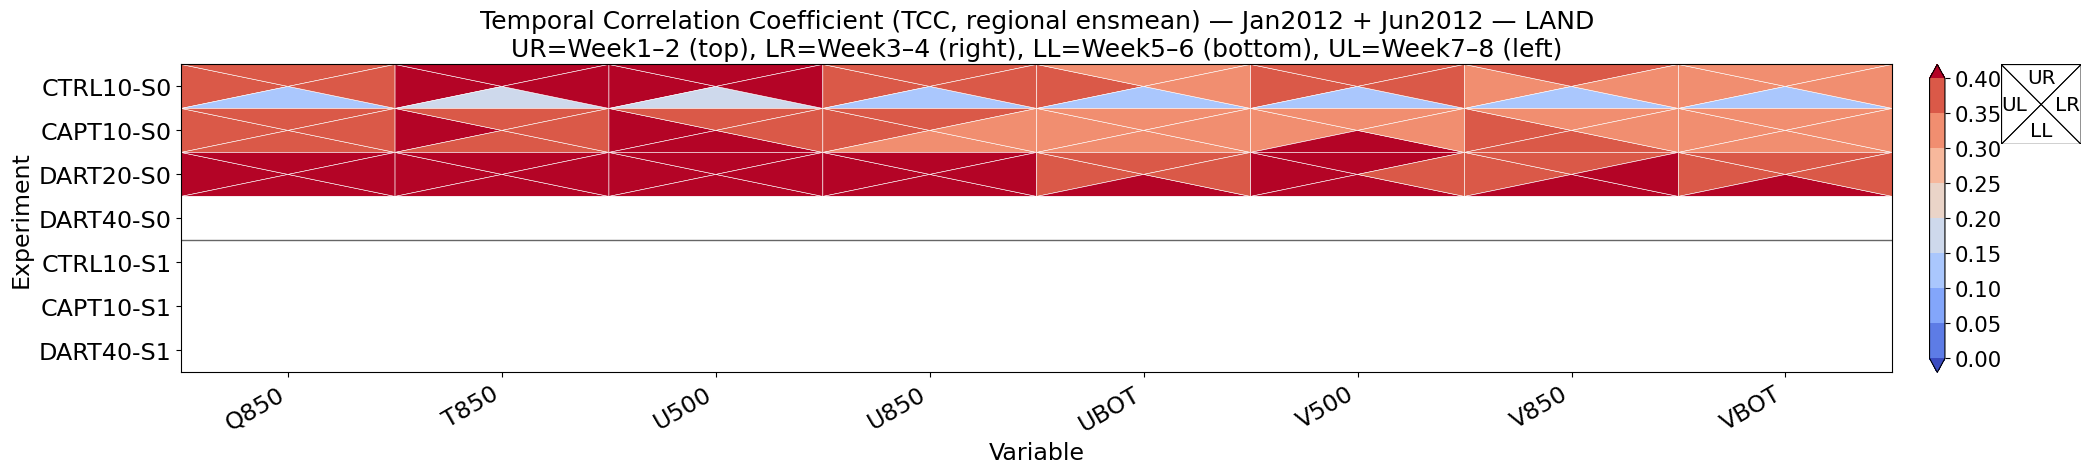

In [81]:
if __name__ == "__main__":
    data_path = Path("/compyfs/zhan391/v3_dart_cda_scratch/diag_output/tcc_rmse_base/regional")
    fig_path = Path("./")
    fig_path.mkdir(parents=True, exist_ok=True)

    # ------------------------------------------------------------
    # Experiments / groups
    # ------------------------------------------------------------
    groups_include = ("Jan2012", "Jun2012")
    
    exp_order = (
        "Jan2012:CTRL10-S0",
        "Jan2012:CAPT10-S0",
        "Jan2012:DART20-S0",
        "Jan2012:DART40-S0",
        "Jun2012:CTRL10-S1",
        "Jun2012:CAPT10-S1",
        "Jun2012:DART40-S1",
    )
    exp_colors = {
        "Jan2012:CTRL10-S0": "#7f7f7f",
        "Jan2012:CAPT10-S0": "#000000",
        "Jan2012:DART20-S0": "#1f77b4",
        "Jan2012:DART40-S0": "#d62728",
        "Jun2012:CTRL10-S1": "#7f7f7f",
        "Jun2012:CAPT10-S1": "#000000",
        "Jun2012:DART40-S1": "#d62728",
    }

    rmse_norm_ctrl_by_group = {
        "Jan2012": "CTRL10-S0",
        "Jun2012": "CTRL10-S1",
    }

    periods_include = ()
    tag = "diag_regional_tcc_rmse_Jan+Jun"

    # ------------------------------------------------------------
    # Variables / obs mapping
    # ------------------------------------------------------------
    vars_include = (
        "UBOT", "VBOT", 
        "U850", "V850","T850", "Q850",
        "U500", "V500","T500", "Q500",
        "U200", "V200","T200", "Q200",
        "OMEGA500", "OMEGA200",
        "PRECT", "TREFHT",
        "PRECSL", "FLUT",
        "FLDS", "FLDSC",
        "FLNS", "FSNS",
        "LHFLX", "SHFLX",
    )
    vars_include = (
        "UBOT", "VBOT", 
        "U850", "V850","T850", "Q850",
        "U500", "V500","T500", "Q500",
    )
    obs_by_var = {"PRECT": "GPM", "FLUT": "NOAA-OLR"}
    default_obs = "ERA5"
    obs_include = ("ERA5", "GPM", "NOAA-OLR")

    file_glob = "s2s_regional_tcc_rmse_*.nc"

    lead_bins = ((1, 14), (15, 28), (29, 42), (43, 56))
    lead_bin_labels = ("Week1–2", "Week3–4", "Week5–6", "Week7–8")

    # For RMSE skill (optional)
    rmse_norm_mode = "baseline"
    rmse_eps = 1e-12

    plot_difference = False
    baseline_exp = None

    # ------------------------------------------------------------
    # Plot cosmetics
    # ------------------------------------------------------------
    guide = True
    guide_loc = "upper right"
    guide_size = 0.20
    edgecolor = "white"
    linewidth = 0.4
    show = True
    xlabel = "Variable"
    ylabel = "Experiment"
    fontz = 18
    fig_size = (24,4)
    
    regions_include = ("GLOBAL", "LAND", "OCEAN", "NINO3.4", "MAR_CONT", "CONUS", "NH_POLAR")

    # ------------------------------------------------------------
    # NEW: Choose ONE group + ONE region to plot
    # ------------------------------------------------------------
    plot_group = ("Jan2012", "Jun2012")   # or "Jan2012"
    plot_region = "LAND"   # must match ds0["region"] values
    metric = "TCC_member_qpre90" #"TCC_regional_ensmean" #"TCC_member_ens_q50" #"TCC_regional_ensmean"
    vmin, vmax, nlev = 0, 0.4, 9
    title_label = "Temporal Correlation Coefficient (TCC, regional ensmean)"
    cb_tvals = np.linspace(vmin, vmax, nlev)
    cmap = "coolwarm"

    # ------------------------------------------------------------
    # Build config
    # ------------------------------------------------------------
    cfg = S2SSkillPlotConfig(
        skill_dir=data_path,
        diag_mode=True,
        file_glob=file_glob,
        groups_include=groups_include,
        periods_include=periods_include,
        obs_include=obs_include,
        obs_by_var=obs_by_var,
        default_obs=default_obs,
        out_dir=fig_path,
        exp_order=tuple(exp_order),
        vars_include=tuple(vars_include),
        lead_bins=lead_bins,
        lead_bin_labels=lead_bin_labels,
        regions_include=regions_include,
        tag=tag,
        baseline_exp=baseline_exp,
        plot_difference=plot_difference,
        rmse_norm_mode=rmse_norm_mode,
        rmse_norm_ctrl_by_group=rmse_norm_ctrl_by_group,
        rmse_eps=rmse_eps,
        debug=True,
    )

    plotter = S2SSkillPlotter(cfg)

    # ------------------------------------------------------------
    # NEW: Plot one region + one group + all variables
    # ------------------------------------------------------------
    plotter.plot_quadrant_heatmap_one_region(
        group=plot_group,
        region=plot_region,
        metric=metric,
        vmin=vmin,
        vmax=vmax,
        nlev=nlev,
        guide=guide,
        guide_loc=guide_loc,
        guide_size=guide_size,
        edgecolor=edgecolor,
        linewidth=linewidth,
        xlabel=xlabel,
        ylabel=ylabel,
        fontz=fontz,
        cb_tvals=cb_tvals,
        title_label=f"{title_label}",
        fig_size=fig_size,
        cmap=cmap,
        show=show,
    )
    

[open_var diag] s2s_regional_tcc_rmse_Jan2012_ERA5_201201-201203_CAPT10-S0_FLDS.nc
[open_var diag] s2s_regional_tcc_rmse_Jan2012_ERA5_201201-201203_CTRL10-S0_FLDS.nc
[open_var diag] s2s_regional_tcc_rmse_Jan2012_ERA5_201201-201203_DART20-S0_FLDS.nc
[open_var diag] s2s_regional_tcc_rmse_Jan2012_ERA5_201201-201203_DART40-S0_FLDS.nc
[open_var diag] s2s_regional_tcc_rmse_Jun2012_ERA5_201206-201208_CAPT10-S1_FLDS.nc
[open_var diag] s2s_regional_tcc_rmse_Jun2012_ERA5_201206-201208_CTRL10-S1_FLDS.nc
[open_var diag] s2s_regional_tcc_rmse_Jun2012_ERA5_201206-201208_DART40-S1_FLDS.nc


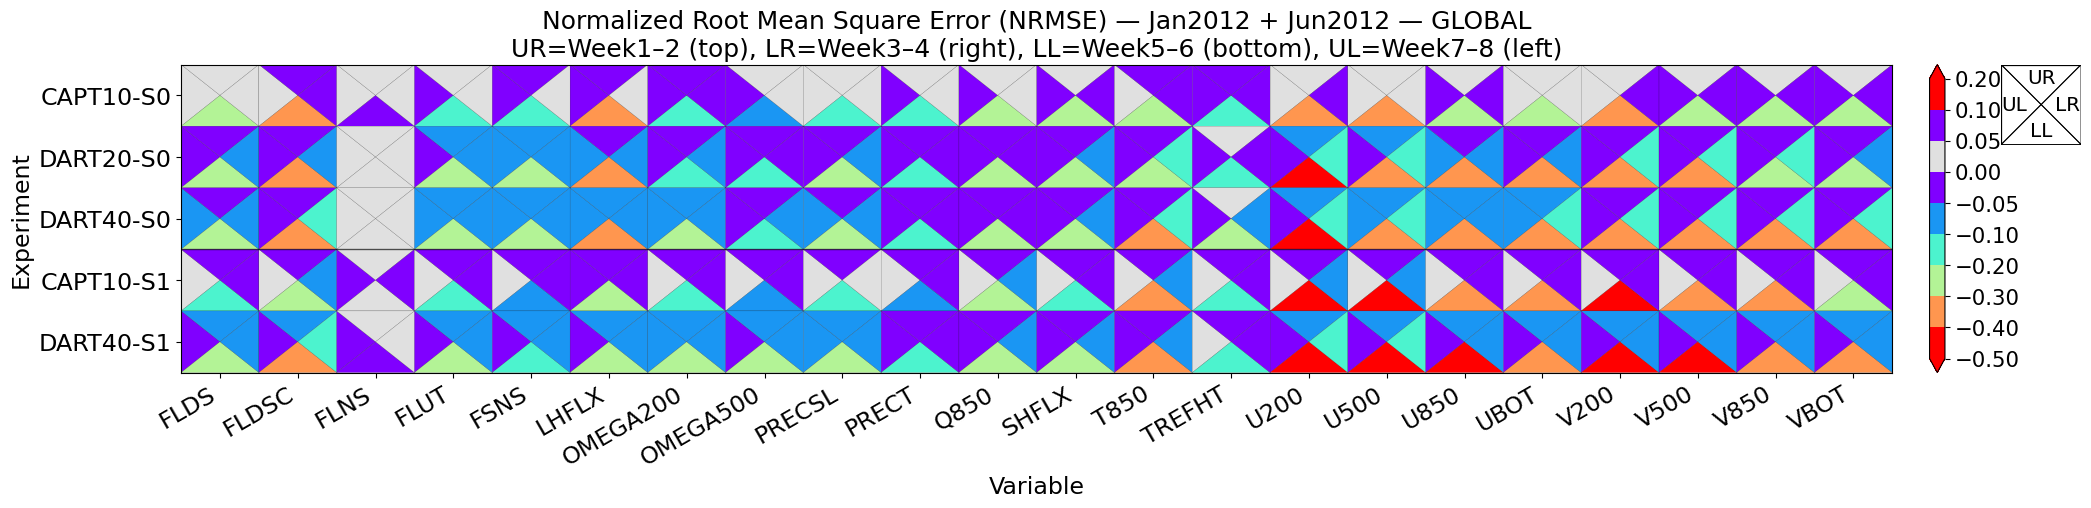

In [63]:
if __name__ == "__main__":
    data_path = Path("/compyfs/zhan391/v3_dart_cda_scratch/diag_output/tcc_rmse_base/regional")
    fig_path = Path("./")
    fig_path.mkdir(parents=True, exist_ok=True)

    # ------------------------------------------------------------
    # Experiments / groups
    # ------------------------------------------------------------
    groups_include = ("Jan2012", "Jun2012")
    
    exp_order = (
        "Jan2012:CTRL10-S0",
        "Jan2012:CAPT10-S0",
        "Jan2012:DART20-S0",
        "Jan2012:DART40-S0",
        "Jun2012:CTRL10-S1",
        "Jun2012:CAPT10-S1",
        "Jun2012:DART40-S1",
    )
    exp_colors = {
        "Jan2012:CTRL10-S0": "#7f7f7f",
        "Jan2012:CAPT10-S0": "#000000",
        "Jan2012:DART20-S0": "#1f77b4",
        "Jan2012:DART40-S0": "#d62728",
        "Jun2012:CTRL10-S1": "#7f7f7f",
        "Jun2012:CAPT10-S1": "#000000",
        "Jun2012:DART40-S1": "#d62728",
    }

    rmse_norm_ctrl_by_group = {
        "Jan2012": "CTRL10-S0",
        "Jun2012": "CTRL10-S1",
    }

    periods_include = ()
    tag = "diag_regional_tcc_rmse_Jan+Jun"

    # ------------------------------------------------------------
    # Variables / obs mapping
    # ------------------------------------------------------------
    vars_include = (
        "UBOT", "VBOT", 
        "U850", "V850","T850", "Q850",
        "U500", "V500","T500", "Q500",
        "U200", "V200","T200", "Q200",
        "OMEGA500", "OMEGA200",
        "PRECT", "TREFHT",
        "PRECSL", "FLUT",
        "FLDS", "FLDSC",
        "FLNS", "FSNS",
        "LHFLX", "SHFLX",
    )

    obs_by_var = {"PRECT": "GPM", "FLUT": "NOAA-OLR"}
    default_obs = "ERA5"
    obs_include = ("ERA5", "GPM", "NOAA-OLR")

    file_glob = "s2s_regional_tcc_rmse_*.nc"

    lead_bins = ((1, 14), (15, 28), (29, 42), (43, 56))
    lead_bin_labels = ("Week1–2", "Week3–4", "Week5–6", "Week7–8")

    # For RMSE skill (optional)
    rmse_norm_mode = "baseline"
    rmse_eps = 1e-12

    plot_difference = False
    baseline_exp = None

    # ------------------------------------------------------------
    # Plot cosmetics
    # ------------------------------------------------------------
    guide = True
    guide_loc = "upper right"
    guide_size = 0.20
    edgecolor = "black"
    linewidth = 0.1
    show = True
    xlabel = "Variable"
    ylabel = "Experiment"
    fontz = 18
    fig_size = (24,4)
    
    regions_include = ("GLOBAL", "LAND", "OCEAN", "NINO3.4", "MAR_CONT", "CONUS", "NH_POLAR")

    # ------------------------------------------------------------
    # NEW: Choose ONE group + ONE region to plot
    # ------------------------------------------------------------
    plot_group = ("Jan2012", "Jun2012")   # or "Jan2012"
    plot_region = "GLOBAL"   # must match ds0["region"] values
    metric = "RMSE_regional_ensmean"
    vmin, vmax, nlev = -0.3, 0.1, 13
    title_label = "Normalized Root Mean Square Error (NRMSE)"
    #cb_tvals = np.linspace(vmin,vmax,nlev) #[-0.4,-0.3,-0.2,-0.1,-0.05,0.0,0.1,0.2,0.3,0.4] #np.linspace(vmin, vmax, nlev)
    #cmap = "RdBu_r"
    
    vmin, vmax = -0.5, 0.2
    cb_tvals = [-0.5, -0.4, -0.3, -0.2, -0.1, -0.05, 0, 0.05, 0.1, 0.2]
    nlev = len(cb_tvals)

    # ------------------------------------------------------------
    # Build config
    # ------------------------------------------------------------
    cfg = S2SSkillPlotConfig(
        skill_dir=data_path,
        diag_mode=True,
        file_glob=file_glob,
        groups_include=groups_include,
        periods_include=periods_include,
        obs_include=obs_include,
        obs_by_var=obs_by_var,
        default_obs=default_obs,
        out_dir=fig_path,
        exp_order=tuple(exp_order),
        vars_include=tuple(vars_include),
        lead_bins=lead_bins,
        lead_bin_labels=lead_bin_labels,
        regions_include=regions_include,
        tag=tag,
        baseline_exp=baseline_exp,
        plot_difference=plot_difference,
        rmse_norm_mode=rmse_norm_mode,
        rmse_norm_ctrl_by_group=rmse_norm_ctrl_by_group,
        rmse_eps=rmse_eps,
        debug=True,
    )

    plotter = S2SSkillPlotter(cfg)

    # ------------------------------------------------------------
    # NEW: Plot one region + one group + all variables
    # ------------------------------------------------------------
    plotter.plot_quadrant_heatmap_one_region(
        group=plot_group,
        region=plot_region,
        metric=metric,
        vmin=vmin,
        vmax=vmax,
        nlev=nlev,
        guide=guide,
        guide_loc=guide_loc,
        guide_size=guide_size,
        edgecolor=edgecolor,
        linewidth=linewidth,
        xlabel=xlabel,
        ylabel=ylabel,
        fontz=fontz,
        cb_tvals=cb_tvals,
        title_label=f"{title_label}",
        cmap=cmap,
        fig_size=fig_size,
        show=show,
    )